# PROJET : Détection de Pneumonie à partir de Radios Thoraciques
## Objectif : Classification binaire avec CNN pré-entraîné + MLflow

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import mlflow
import mlflow.tensorflow

mlflow.tensorflow.autolog()

## 1. Chargement et exploration des données

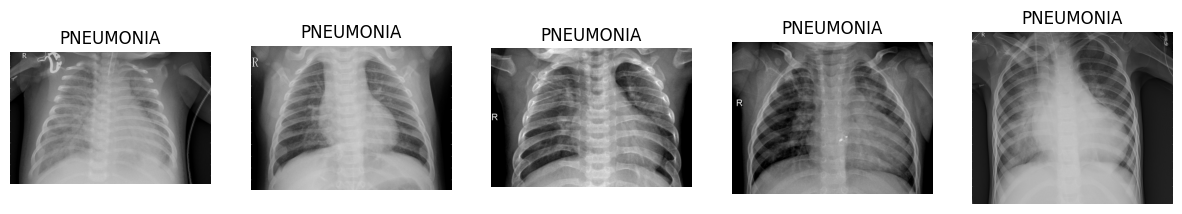

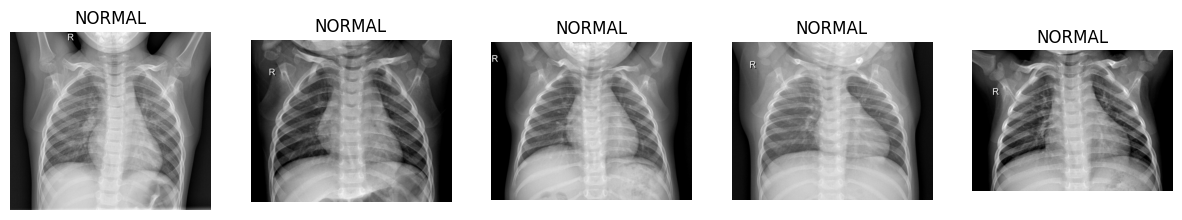

In [9]:
data_dir = "data\\chest_xray"

def show_sample_images(dataset_path, label, n=5):
    fig, axes = plt.subplots(1, n, figsize=(15, 5))
    valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    all_files = os.listdir(os.path.join(dataset_path, label))
    image_paths = [f for f in all_files if f.lower().endswith(valid_extensions)]
    for i, img in enumerate(image_paths[:n]):
        img_path = os.path.join(dataset_path, label, img)
        image = plt.imread(img_path)
        axes[i].imshow(image, cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(label)
    plt.show()

show_sample_images(os.path.join(data_dir, 'train'), 'PNEUMONIA')
show_sample_images(os.path.join(data_dir, 'train'), 'NORMAL')

## 2. Prétraitement des données

In [10]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=15,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'train'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'train'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(data_dir, 'test'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## 3. Création du modèle avec EfficientNetB0

In [11]:
base_model = EfficientNetB0(include_top=False, input_shape=img_size + (3,), weights='imagenet', pooling='avg')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## 4. Entraînement du modèle avec MLflow

In [12]:
with mlflow.start_run(run_name="EfficientNetB0_Pneumonia"):
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=5
    )

2025/05/22 15:53:01 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/05/22 15:53:01 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
c:\Users\Utilisateur\Desktop\simplon_dev_ia\ML_Deeplearning\Projet_Transfer_Learning\.venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7383 - loss: 0.5895

131/131 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.7384 - loss: 0.5894 - val_accuracy: 0.7430 - val_loss: 0.5713
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.7404 - loss: 0.5754 - val_accuracy: 0.7430 - val_loss: 0.5885
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7517 - loss: 0.5666

131/131 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.7517 - loss: 0.5667 - val_accuracy: 0.7430 - val_loss: 0.5706
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.7407 - loss: 0.5748 - val_accuracy: 0.7430 - val_loss: 0.5774
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7500 - loss: 0.5657

131/131 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.7500 - loss: 0.5658 - val_accuracy: 0.7430 - val_loss: 0.5695


2025/05/22 16:08:37 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: '>=' not supported between instances of 'slice' and 'int'
2025/05/22 16:08:37 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/22 16:08:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


## 5. Évaluation du modèle

In [ ]:
test_generator.reset()
pred_probs = model.predict(test_generator)
preds = (pred_probs > 0.5).astype(int)
y_true = test_generator.classes

print(classification_report(y_true, preds))

cm = confusion_matrix(y_true, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

roc_auc = roc_auc_score(y_true, pred_probs)
fpr, tpr, _ = roc_curve(y_true, pred_probs)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC")
plt.legend()
plt.show()

## 6. Conclusion

In [ ]:
"""
Résumé des résultats :
- Accuracy : à compléter
- F1-score : à compléter
- AUC : à compléter

Discussion :
- Forces du modèle
- Limites
- Améliorations possibles
"""

## 7. Sauvegarde du modèle

In [ ]:
model.save("pneumonia_classifier.h5")
mlflow.log_artifact("pneumonia_classifier.h5")

In [4]:
from collections import Counter

def count_duplicates(directory):
    all_files = []
    for root, _, files in os.walk(directory):
        for file in files:
            all_files.append(file)
    file_counts = Counter(all_files)
    duplicates = {fname: count for fname, count in file_counts.items() if count > 1}
    print(f"Nombre total de fichiers dupliqués : {sum(duplicates.values())}")
    print("Fichiers dupliqués (nom: nombre d'occurrences) :")
    for fname, count in duplicates.items():
        print(f"{fname}: {count}")

count_duplicates(data_dir)

Nombre total de fichiers dupliqués : 8
Fichiers dupliqués (nom: nombre d'occurrences) :
.DS_Store: 8


In [7]:
import glob

# Récupérer tous les chemins de fichiers dans data/chest_xray/test
test_dir = os.path.join(data_dir, 'test')
test_files = set([os.path.basename(f) for f in glob.glob(os.path.join(test_dir, '*')) if os.path.isfile(f)])

# Les fichiers listés dans df_files pour le split 'test'
df_test_files = set(df_files[df_files['split'] == 'test']['filename'])

# Intersection pour voir les fichiers présents dans les deux
common_files = test_files.intersection(df_test_files)
print(f"Nombre de fichiers communs : {len(common_files)}")
print("Exemples de fichiers communs :", list(common_files)[:10])

Nombre de fichiers communs : 0
Exemples de fichiers communs : []
